In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib')
from variable_print import p,ps,pst

In [3]:
import gymnasium as gym
env = gym.make("CartPole-v1", render_mode="rgb_array")
print(gym.__version__)  #0.25.2
print("="*10)
print('State space: ', env.observation_space)
print('Action space: ', env.action_space)

1.2.0
State space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:  Discrete(2)


# Neural Network 적용

In [4]:
import tensorflow as tf
import keras
import keras.layers as layers
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from collections import deque
import numpy as np
import random

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Model

### Neural Model

In [5]:
lr = 0.0005 # defalut : 0.001

input_d = env.observation_space.shape[0]# 4(position,velocity,angle,angular_velocity)
output_d = env.action_space.n           # 2(left,right)

def Network():
    model=Sequential()
    model.add(keras.Input(shape=(input_d,)))        # input:4
    model.add(Dense(128, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(output_d, activation='linear')) #output:(2,)
    model.compile(loss='mse',optimizer=tf.optimizers.Adam(learning_rate=lr))
    return model

q_network = Network()
t_network = Network()
q_network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,410 (68.01 KB)

 Trainable params: 17,410 (68.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# # import random
# gamma     = 0.99 # 할인율

# # DQN Tranining
# def model_learning():
#     # RM에서 dataset sampling #RM:replay_memory(s,a,r,s1,done)
#     mini_batch = random.sample(RM, batch_siz)
#     state = np.array([mini_batch[i][0] for i in range(batch_siz)]) # s(4,)
#     action = np.array([mini_batch[i][1] for i in range(batch_siz)])# a
#     reward = np.array([mini_batch[i][2] for i in range(batch_siz)])# r
#     next_s = np.array([mini_batch[i][3] for i in range(batch_siz)])# s'(4,)
#     done = np.array([mini_batch[i][4] for i in range(batch_siz)])  # T

#     # Q-Network에서 Q value prediction
#     target     = q_network.predict(state, verbose=0)  #q:(bs,a)<-(bs,s)
#     # Target-Network에서 Q' value prediction
#     target_val = t_network.predict(next_s, verbose=0) #q':(bs,a')<-(bs,s')

#     # Target value update
#     for i in range(batch_siz):
#         if done[i]:  # Terminal 이면 현재 reward가 Target
#             target[i][action[i]] = reward[i]
#         else:        # Target += r+ gamma*max_aQ'(s',a')Q러닝식을 적용
#             target[i][action[i]] = reward[i] + gamma * np.max(target_val[i])

#     history = q_network.fit(state, target, batch_siz, epochs, verbose=0)
#     return history.history['loss'][0]

In [6]:
import random

gamma = 0.99

# DQN Training (수정된 함수)
def model_learning():
    # 1. RM에서 미니배치 샘플링
    mini_batch = random.sample(RM, batch_siz)
    state = np.array([sample[0] for sample in mini_batch], dtype=np.float32)
    action = np.array([sample[1] for sample in mini_batch], dtype=np.int32)
    reward = np.array([sample[2] for sample in mini_batch], dtype=np.float32)
    next_s = np.array([sample[3] for sample in mini_batch], dtype=np.float32)
    done = np.array([sample[4] for sample in mini_batch], dtype=np.float32) # bool을 float으로 변환 (True=1.0, False=0.0)

    # 2. 타겟 Q 값 계산 (Vectorized)
    # Target-Network에서 다음 상태(next_s)의 Q' 값들을 예측
    target_val = t_network.predict(next_s, verbose=0)
    # 각 샘플에 대해 Q' 값들 중 최댓값을 선택
    max_q_prime = np.max(target_val, axis=1)

    # 벨만 최적 방정식에 따라 타겟값 계산
    # 게임이 종료(done=1.0)된 경우: target = reward
    # 게임이 진행 중(done=0.0)인 경우: target = reward + gamma * max_q'
    target = reward + gamma * max_q_prime * (1 - done)

    # 3. GradientTape를 이용한 모델 학습
    with tf.GradientTape() as tape:
        # Q-Network에서 현재 상태(state)의 Q 값들을 예측
        q_values = q_network(state)

        # 실제 선택했던 행동(action)에 해당하는 Q 값만 추출
        # 예를 들어, action이 [1, 0, 1]이면, 0번 샘플에선 1번 행동의 Q값, 1번 샘플에선 0번 행동의 Q값을 가져옴
        action_indices = tf.stack([tf.range(batch_siz, dtype=tf.int32), action], axis=1)
        q_for_action = tf.gather_nd(q_values, action_indices)

        # 예측된 Q값(q_for_action)과 목표 Q값(target) 사이의 손실(loss) 계산
        loss = loss_function(target, q_for_action)

    # 손실(loss)을 기반으로 경사도(gradient) 계산
    grads = tape.gradient(loss, q_network.trainable_variables)

    # 계산된 경사도를 이용해 Q-Network의 가중치 업데이트
    optimizer.apply_gradients(zip(grads, q_network.trainable_variables))

    return loss.numpy()

In [7]:
def update_t_network():
    t_network.set_weights(q_network.get_weights())
    return

## epsilon-greedy scheduling

In [8]:
def eps_schedule(step, eps_start, eps_decay, plot= False):
    eps_decay_step =  n_episode // 3
    epsilon = max(0.01, eps_start*eps_decay**(step//eps_decay_step))
    if plot == True :
        epsilon_l=[]
        for step in range(n_episode):
            epsilon = max(0.01, eps_start*eps_decay**(step//eps_decay_step))
            epsilon_l.append(epsilon)
        plt.plot(epsilon_l)
        plt.grid()
        plt.show()
    return epsilon

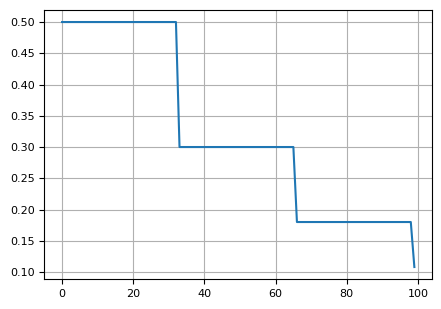

In [9]:
n_episode = 100
epsilon = eps_start = 0.5   # epsilon 초기값
eps_decay = 0.6   # 감소율

_ = eps_schedule(0, eps_start, eps_decay, plot=True)

In [10]:
def get_action(step, state): #epsilon greedy policy
    epsilon = eps_schedule(step,eps_start,eps_decay)
    if(np.random.random() < epsilon): # exploration: eps-greedy
        a = np.random.randint(0, env.action_space.n)
    else:                             # exploitation
        ## Q-Network에서 q값 추정
        q = q_network.predict(np.reshape(state,[1,4]), verbose=0)
        a = np.argmax(q[0])           # greedy
    return a, epsilon

In [11]:
%%time

target_update_freq = 5 # episodes
epochs = 1
batch_siz = 64 #128
scores=[0]      # Eps.단위
losses=[]
max_score=50    # break 조건

q_network = Network()
t_network = Network()
RM=deque(maxlen=10000)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_function = tf.keras.losses.MeanSquaredError()

# RL Training loop
for e in range(1,n_episode+1):
    s = env.reset()
    if isinstance(s, tuple): s = s[0]

    score = loss = 0                # Eps.별 보상
    while True :                    # Termination 까지
        a, epsilon = get_action(e, s)# epsilon greedy policy
        ns, r, done, _, _ = env.step(a)# step(a)
        RM.append((s,a,r,ns,done))
        ## Q-Network Training
        if len(RM) > batch_siz * 1:
            loss = model_learning() # step마다 Q-Net Training
        if loss is not None: losses.append(loss)
        s = ns
        score += r                  # episode내 reward
        if done : break
    # 주기적으로 Target Network 업데이트
    if e % target_update_freq == 0:
        update_t_network() # T-Net <- Q-Net
        print(f"Episode {e}: Target network updated.")
    # update_t_network() # T-Net <- Q-Net
    mean_score = np.mean(scores[-min(10,len(scores)):])
    print(f"Eps.[{e:03d}], mean score:{int(mean_score):.1f}",end="")
    print(f",loss:{loss:.2f}, Epsilon:{epsilon:.2f}, Length_RM:{len(RM)}")
    scores.append(score), losses.append(loss)
    # 목표 점수 도달 시 조기 종료
    if mean_score >= 100 :
        print("목표 점수 도달! 학습을 종료합니다.")
        break

env.close()
# Wall time: 4min

Eps.[001], mean score:0.0,loss:0.00, Epsilon:0.50, Length_RM:37
Eps.[002], mean score:18.0,loss:0.04, Epsilon:0.50, Length_RM:106
Eps.[003], mean score:35.0,loss:0.10, Epsilon:0.50, Length_RM:121
Eps.[004], mean score:30.0,loss:0.05, Epsilon:0.50, Length_RM:161
Episode 5: Target network updated.
Eps.[005], mean score:32.0,loss:0.00, Epsilon:0.50, Length_RM:228
Eps.[006], mean score:38.0,loss:0.02, Epsilon:0.50, Length_RM:301
Eps.[007], mean score:43.0,loss:0.03, Epsilon:0.50, Length_RM:352
Eps.[008], mean score:44.0,loss:0.00, Epsilon:0.50, Length_RM:381
Eps.[009], mean score:42.0,loss:0.01, Epsilon:0.50, Length_RM:472
Episode 10: Target network updated.
Eps.[010], mean score:47.0,loss:0.03, Epsilon:0.50, Length_RM:522
Eps.[011], mean score:52.0,loss:0.01, Epsilon:0.50, Length_RM:562
Eps.[012], mean score:52.0,loss:0.17, Epsilon:0.50, Length_RM:591
Eps.[013], mean score:48.0,loss:0.01, Epsilon:0.50, Length_RM:602
Eps.[014], mean score:48.0,loss:0.01, Epsilon:0.50, Length_RM:637
Episode

    Episode 35: Target network updated.
    Eps.[035], mean score:43.0,loss:0.38, Epsilon:0.30, Length_RM:1137
    Eps.[036], mean score:61.0,loss:0.06, Epsilon:0.30, Length_RM:1409
    Eps.[037], mean score:87.0,loss:0.04, Epsilon:0.30, Length_RM:1523
    Eps.[038], mean score:98.0,loss:0.01, Epsilon:0.30, Length_RM:1763
    Eps.[039], mean score:118.0,loss:0.10, Epsilon:0.30, Length_RM:1868
    목표 점수 도달! 학습을 종료합니다.
    CPU times: user 3min 55s, sys: 9.36 s, total: 4min 4s
    Wall time: 4min



In [ ]:
def q_net_eval(n_episode):
  mean_score = 0
  for i in range(n_episode):
      s = env.reset()
      if isinstance(s, tuple): s = s[0]

      score = 0
      while True :
          a = q_network.predict(s.reshape(1,4),verbose=0)
          a = np.argmax(a)
          s, r, done, _,_ = env.step(a)
          score += r
          if done : break
      mean_score += score/n_episode
  print(f'Evaluation score:{mean_score:.1f}')

q_net_eval(5)

Evaluation score:134.6


In [ ]:
# Loss 그래프 (Moving Average)
def plot_moving_avg(data, window_size):
    moving_avg = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    plt.plot(moving_avg)

plt.figure(figsize=(10,3))
plt.subplot(121)
plt.title(f"DQN scores for CartPole,Max score:{max(scores)}")
plt.ylabel('Score')
plt.xlabel('Episode')
plt.plot(scores)
plt.grid()

plt.subplot(122)
plot_moving_avg(losses, 100) # Loss는 변동이 크므로 이동 평균으로 시각화
plt.semilogy()
plt.grid()
plt.show()

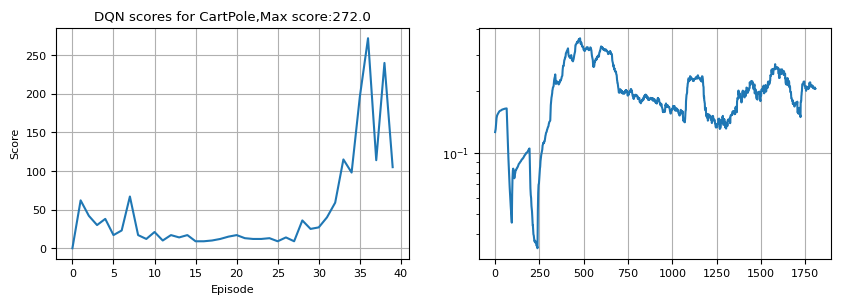

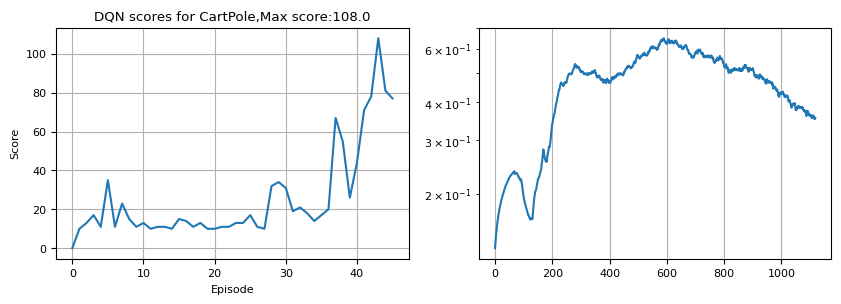

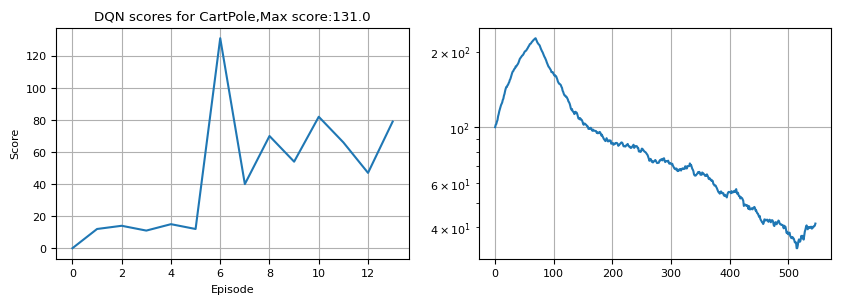

# Evaluation  

In [ ]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env_v = wrap_env(env, path=path, name_prefix="q2")

/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:296: UserWarning: WARN: Overwriting existing videos at /content/gdrive/MyDrive/Colab Notebooks/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


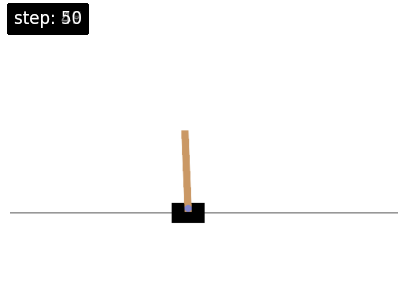

In [ ]:
state = env_v.reset()
if isinstance(state, tuple): state = state[0]

cnt = 0
while True:
    render_as_image(env_v,step=cnt)
    predict = q_network.predict(state.reshape(1,4),verbose=0)
    action = np.argmax(predict)
    state, reward, done, info,_ = env_v.step(action)
    if done:  break;
    cnt += 1
    if cnt > 50 : break
env_v.close()

In [ ]:
show_video(path=path,name_prefix='q2')

/content/gdrive/MyDrive/Colab Notebooks/video/q2-episode-0.mp4


In [ ]:
show_video(path=path,name_prefix='q2')

/content/gdrive/MyDrive/Colab Notebooks/video/q2-episode-1.mp4


# 실습과제   
## Hyper Parameter tuning해 보자  
### n_episode = 75 로 고정하고 다음을 조정해서 성능을 개선해 보자  
#### eps_start = 0.5   
#### batch_siae = 128  
#### epochs = 1  
#### len(RM) > batch_size * 3